# Person specfic analysis (i.e, scores)

In [1]:
import pandas as pd

input_folder_base = "/Users/paulh/runs-svn/matsim-berlin/autofrei/1pct-v6.4/berlin-autofrei-v6.4-baseCaseCtdExtended"
input_folder_policy = "/Users/paulh/runs-svn/matsim-berlin/autofrei/1pct-v6.4/berlin-autofrei-v6.4-policy"


def read_persons(input_folder):
    # person column is a string
    df = pd.read_csv(input_folder + "/berlin-v6.4.output_persons.csv.zst", sep=";", low_memory=False,
                     dtype={"person": "string"}, )
    df["monetarized_score"] = df["executed_score"] / df["marginalUtilityOfMoney"]
    return df


base_persons = read_persons(input_folder_base)
policy_persons = read_persons(input_folder_policy)
base_persons

,person,executed_score,first_act_x,first_act_y,first_act_type,RegioStaR7,age,ars,bikeAvail,carAvail,...,subpopulation,ref_id,ref_modes,ref_weight,lor,zone,purpose,tourStartArea,vehicleTypes,monetarized_score
0,bb_00005f6f,99.809194,766625.23,5872598.05,home_86400,7.0,40.0,1.206858e+11,always,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.712185
1,bb_000820ed,139.682723,820356.82,5799630.27,home_86400,4.0,63.0,1.206102e+11,never,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.244889
2,bb_000905ff,152.989806,784159.24,5838621.55,home_86400,3.0,13.0,1.206501e+11,always,never,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.493950
3,bb_000f0451,158.485441,807901.68,5844018.06,home_86400,3.0,47.0,1.206002e+11,always,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.110424
4,bb_001079c1,0.000000,772999.38,5836225.31,home_86400,3.0,60.0,1.206301e+11,never,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52258,goodsTraffic_re_vkz.1941_5_4,16.923088,812259.72,5830204.43,commercial_start,NaN,NaN,NaN,NaN,NaN,...,goodsTraffic,NaN,NaN,NaN,NaN,NaN,5.0,re_vkz.1941,org.matsim.vehicles.PersonVehicleTypes@73c4bcae,NaN
52259,goodsTraffic_re_vkz.1942_5_17,78.359953,811592.59,5831447.76,commercial_start,NaN,NaN,NaN,NaN,NaN,...,goodsTraffic,NaN,NaN,NaN,NaN,NaN,5.0,re_vkz.1942,org.matsim.vehicles.PersonVehicleTypes@5a828061,NaN
52260,goodsTraffic_re_vkz.1951_4_8,70.183513,812516.20,5829825.07,commercial_start,NaN,NaN,NaN,NaN,NaN,...,goodsTraffic,NaN,NaN,NaN,NaN,NaN,4.0,re_vkz.1951,org.matsim.vehicles.PersonVehicleTypes@7d596095,NaN
52261,goodsTraffic_re_vkz.1952_3_1,-2.813844,812367.46,5831015.38,commercial_start,NaN,NaN,NaN,NaN,NaN,...,goodsTraffic,NaN,NaN,NaN,NaN,NaN,3.0,re_vkz.1952,org.matsim.vehicles.PersonVehicleTypes@16f76f2a,NaN


In [2]:
# join bass and policy persons based on "person" column. retain all columns.
joined = base_persons.merge(policy_persons, on="person", suffixes=("_base", "_policy"))
joined = joined[joined["subpopulation_base"] == "person"]
joined

,person,executed_score_base,first_act_x_base,first_act_y_base,first_act_type_base,RegioStaR7_base,age_base,ars_base,bikeAvail_base,carAvail_base,...,subpopulation_policy,ref_id_policy,ref_modes_policy,ref_weight_policy,lor_policy,zone_policy,purpose_policy,tourStartArea_policy,vehicleTypes_policy,monetarized_score_policy
0,bb_00005f6f,99.809194,766625.230000,5.872598e+06,home_86400,7.0,40.0,1.206858e+11,always,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.986872
1,bb_000820ed,139.682723,820356.820000,5.799630e+06,home_86400,4.0,63.0,1.206102e+11,never,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.244889
2,bb_000905ff,152.989806,784159.240000,5.838622e+06,home_86400,3.0,13.0,1.206501e+11,always,never,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.493950
3,bb_000f0451,158.485441,807901.680000,5.844018e+06,home_86400,3.0,47.0,1.206002e+11,always,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.110424
4,bb_001079c1,0.000000,772999.380000,5.836225e+06,home_86400,3.0,60.0,1.206301e+11,never,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48963,berlin_fff8f001,122.340066,807065.141931,5.817084e+06,home_86400,1.0,11.0,1.100000e+11,always,never,...,person,NaN,NaN,NaN,8041040.0,8.0,NaN,NaN,NaN,154.243139
48964,berlin_fffa1c81,121.510197,798450.818532,5.829558e+06,home_86400,1.0,57.0,1.100000e+11,never,always,...,person,NaN,NaN,NaN,1011402.0,1.0,NaN,NaN,NaN,138.060190
48965,berlin_fffa2ce6,148.686783,786942.622696,5.830594e+06,home_86400,1.0,19.0,1.100000e+11,always,always,...,person,NaN,NaN,NaN,5030730.0,5.0,NaN,NaN,NaN,19.197534
48966,berlin_fffafb83,156.750857,805117.857177,5.840357e+06,home_86400,1.0,86.0,1.100000e+11,never,always,...,person,NaN,NaN,NaN,3010102.0,3.0,NaN,NaN,NaN,267.151075


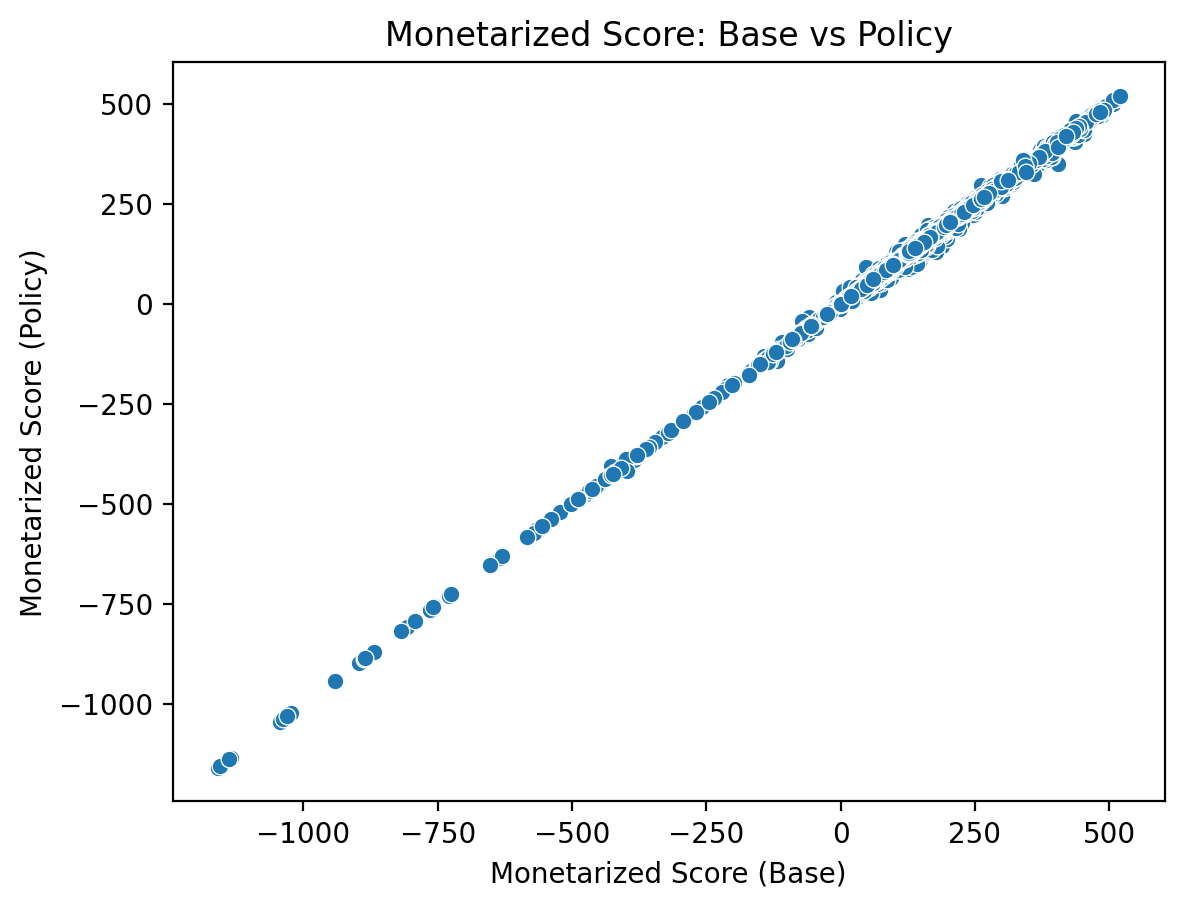

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'


sns.scatterplot(data=joined, x="monetarized_score_base", y="monetarized_score_policy")
plt.xlabel("Monetarized Score (Base)")
plt.ylabel("Monetarized Score (Policy)")
plt.title("Monetarized Score: Base vs Policy")
plt.show()

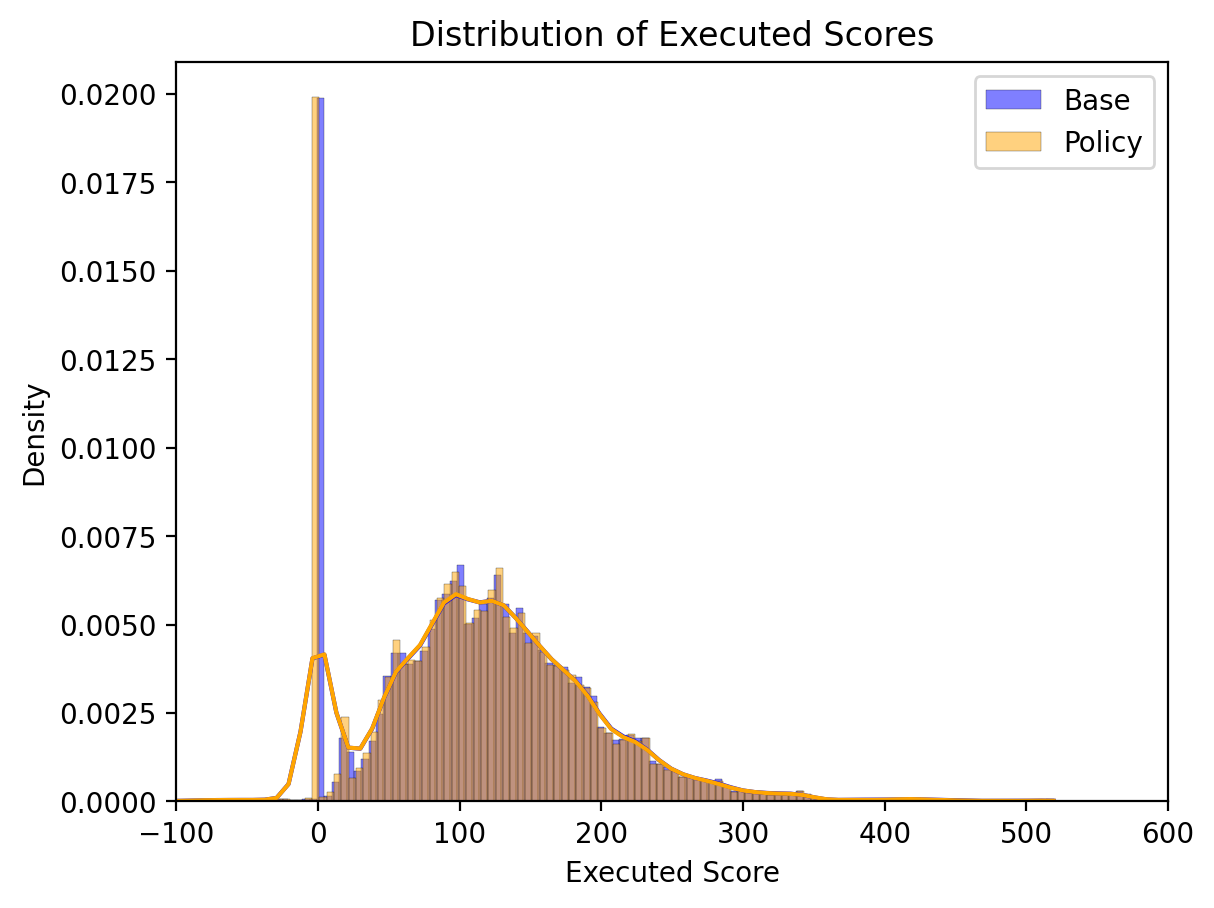

In [4]:
# plot the distribution of executed_score_base and executed_score_policy as histograms
sns.histplot(joined["monetarized_score_base"], color="blue", label="Base", kde=True, stat="density")
sns.histplot(joined["monetarized_score_policy"], color="orange", label="Policy", kde=True, stat="density")

# restrict x axis to -100 to 200
plt.xlim(-100, 600)
plt.xlabel("Executed Score")
plt.ylabel("Density")
plt.title("Distribution of Executed Scores")
plt.legend()
plt.show()

In [5]:
# plot the diff between monetarized_score_base and monetarized_score_policy as a histogram
joined["monetarized_score_diff"] = joined["monetarized_score_policy"] - joined["monetarized_score_base"]
print(joined["monetarized_score_diff"].describe())


count    48968.000000
mean        -0.223221
std          2.147601
min        -54.858062
25%         -0.000059
50%          0.000000
75%          0.000000
max         45.031186
Name: monetarized_score_diff, dtype: float64


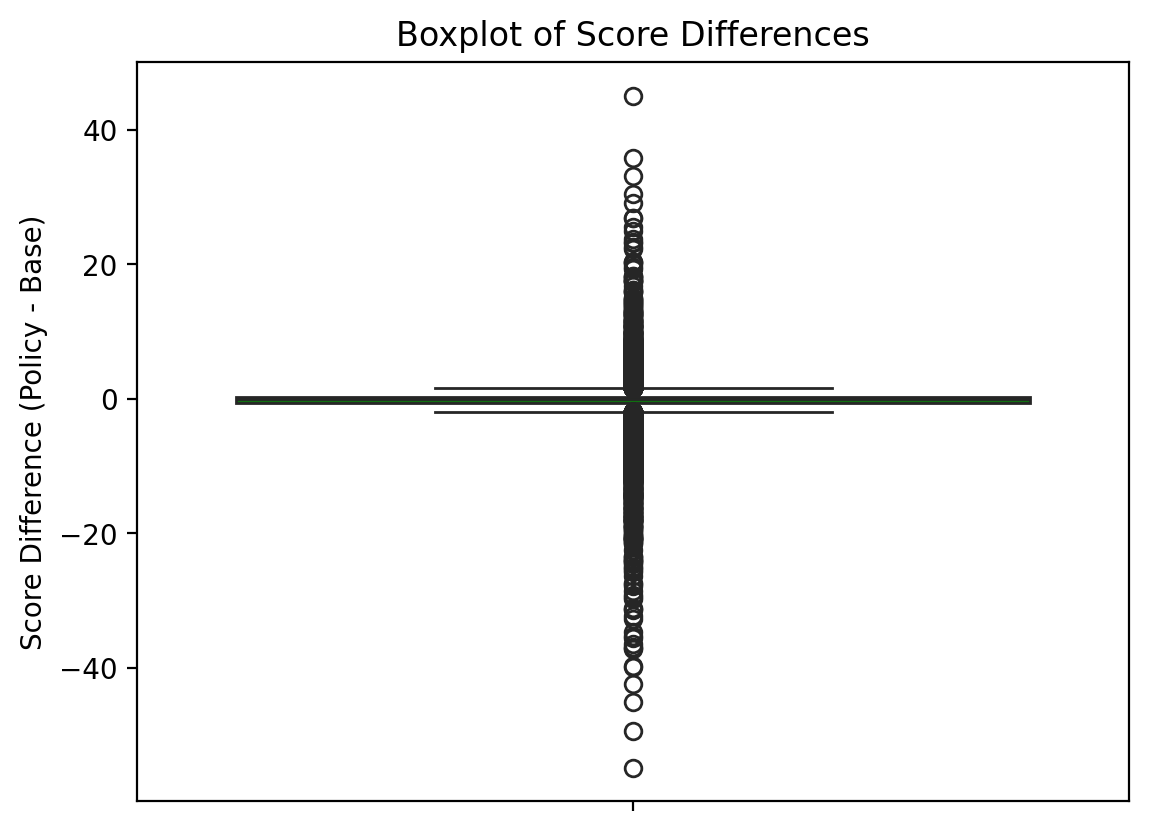

In [6]:
changed_persons = joined.loc[joined["monetarized_score_diff"] != 0.0].copy()

sns.boxplot(data=changed_persons, y="monetarized_score_diff", color="green")
plt.ylabel("Score Difference (Policy - Base)")
plt.title("Boxplot of Score Differences")
plt.show()


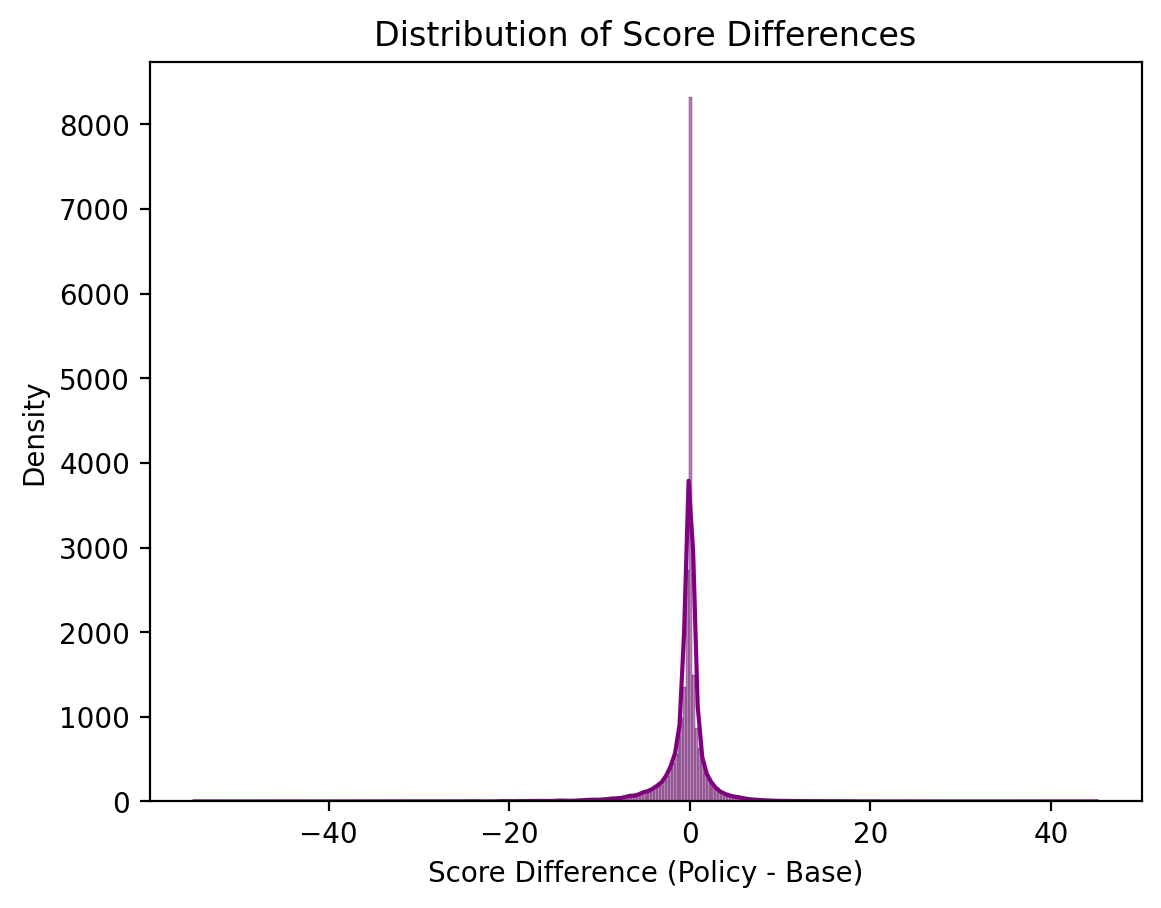

In [7]:
# create a distribution of the score differences
sns.histplot(changed_persons["monetarized_score_diff"], color="purple", kde=True)
plt.xlabel("Score Difference (Policy - Base)")
plt.ylabel("Density")
plt.title("Distribution of Score Differences")
plt.show()

In [8]:
changed_persons["score_diff"] = changed_persons["executed_score_policy"] - changed_persons["executed_score_base"]
changed_persons

,person,executed_score_base,first_act_x_base,first_act_y_base,first_act_type_base,RegioStaR7_base,age_base,ars_base,bikeAvail_base,carAvail_base,...,ref_modes_policy,ref_weight_policy,lor_policy,zone_policy,purpose_policy,tourStartArea_policy,vehicleTypes_policy,monetarized_score_policy,monetarized_score_diff,score_diff
0,bb_00005f6f,99.809194,766625.230000,5.872598e+06,home_86400,7.0,40.0,1.206858e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.986872,1.274687,1.851571
5,bb_00181603,107.869846,802705.930000,5.801373e+06,home_86400,3.0,33.0,1.207203e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.473141,0.557655,0.354024
9,bb_0025ad89,150.570761,788827.630000,5.804673e+06,home_86400,3.0,46.0,1.207202e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,255.808025,-0.810291,-0.475438
10,bb_00279ecb,133.462883,787045.000000,5.850799e+06,home_86400,3.0,54.0,1.206503e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.444961,0.006376,0.010579
11,bb_002ff972,102.263150,818085.560000,5.864592e+06,home_86400,3.0,50.0,1.206001e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87.203464,0.059729,0.070092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48953,berlin_ffe4d871,115.109450,806317.118164,5.825152e+06,home_86400,1.0,46.0,1.100000e+11,always,always,...,NaN,NaN,11051330.0,11.0,NaN,NaN,NaN,71.384138,0.045422,0.073291
48954,berlin_ffe5b2a1,89.535287,797944.005988,5.833287e+06,home_86400,1.0,60.0,1.100000e+11,always,always,...,NaN,NaN,3040614.0,3.0,NaN,NaN,NaN,131.200804,4.824129,3.417797
48958,berlin_fff07279,133.054787,797530.620280,5.826034e+06,home_86400,1.0,29.0,1.100000e+11,always,always,...,NaN,NaN,2010101.0,2.0,NaN,NaN,NaN,79.788881,-0.403743,-0.669886
48960,berlin_fff153af,141.343973,808122.291904,5.818883e+06,home_86400,1.0,33.0,1.100000e+11,always,always,...,NaN,NaN,9020701.0,9.0,NaN,NaN,NaN,142.902122,0.410224,0.406919


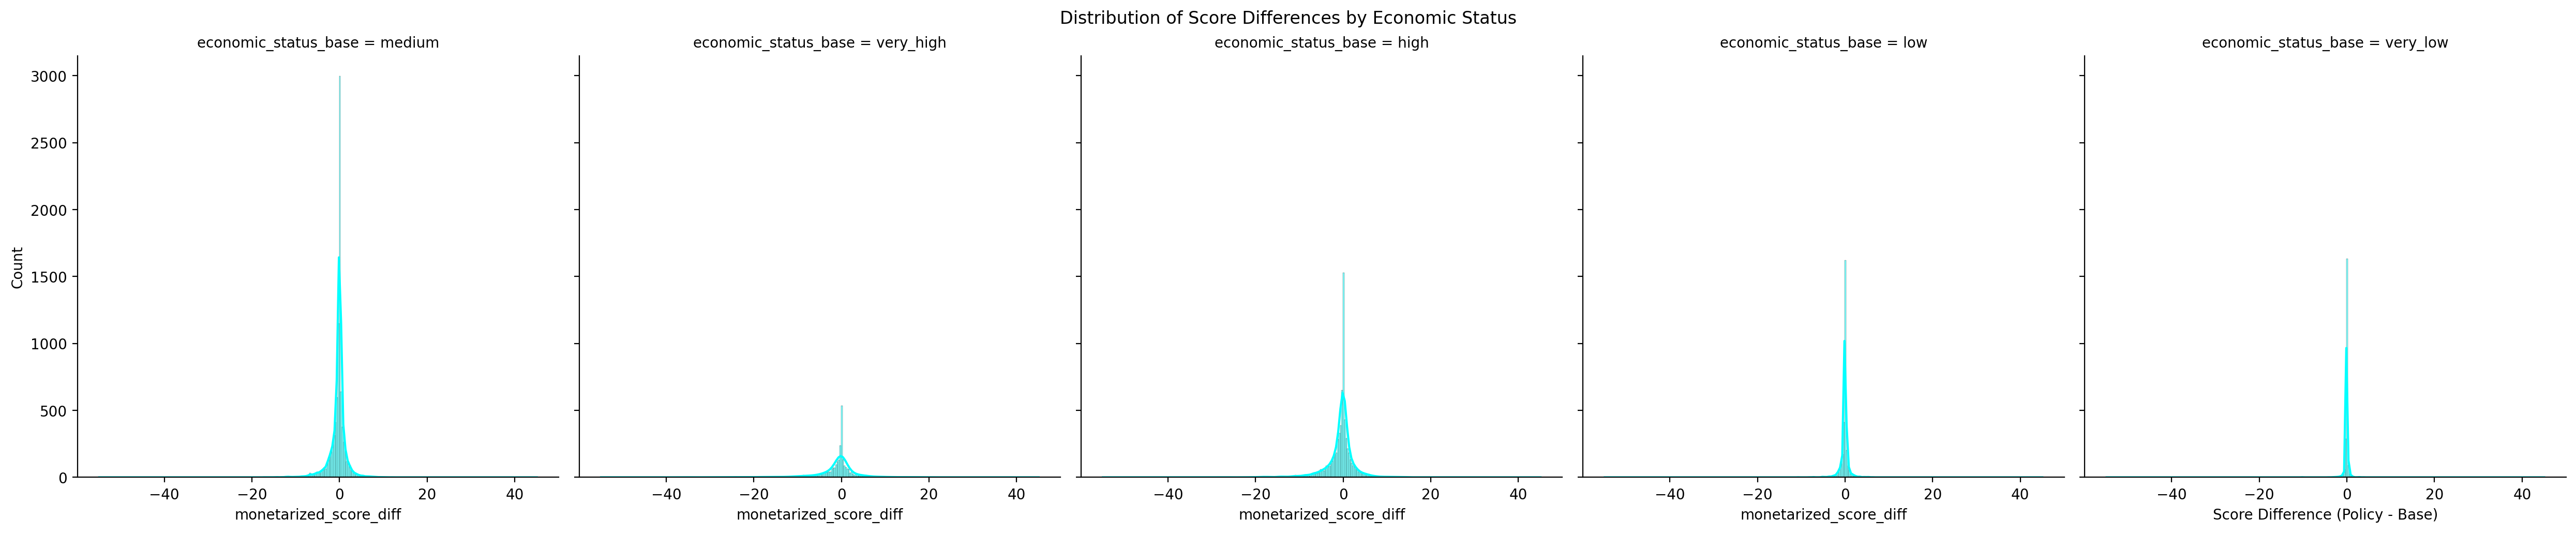

In [9]:
# do a facet plot: for each economic_status plot the distribution of score differences
sns.displot(data=changed_persons, x="monetarized_score_diff", col="economic_status_base", color="cyan", kde=True)
plt.xlabel("Score Difference (Policy - Base)")
plt.ylabel("Density")
plt.suptitle("Distribution of Score Differences by Economic Status", y=1.02)
plt.show()

In [10]:
# for each economic_status describe the score differences
for status in changed_persons["economic_status_base"].unique():
    subset = changed_persons[changed_persons["economic_status_base"] == status]
    print(f"Economic Status: {status}")
    print(subset["monetarized_score_diff"].describe())
    print("\n")


Economic Status: medium
count    9065.000000
mean       -0.343090
std         2.010926
min       -29.813615
25%        -0.674024
50%        -0.003158
75%         0.201433
max        22.558854
Name: monetarized_score_diff, dtype: float64


Economic Status: very_high
count    2723.000000
mean       -1.047137
std         5.474518
min       -54.858062
25%        -1.996992
50%        -0.129245
75%         0.495551
max        45.031186
Name: monetarized_score_diff, dtype: float64


Economic Status: high
count    6942.000000
mean       -0.669774
std         3.792445
min       -49.360854
25%        -1.347462
50%        -0.051430
75%         0.442408
max        30.463611
Name: monetarized_score_diff, dtype: float64


Economic Status: low
count    2.985000e+03
mean    -8.821493e-02
std      9.270948e-01
min     -1.074838e+01
25%     -1.706331e-01
50%     -2.842171e-14
75%      5.594855e-02
max      6.310765e+00
Name: monetarized_score_diff, dtype: float64


Economic Status: very_low
count    2.1

In [11]:
joined.sort_values(by=["monetarized_score_diff"], ascending=False).head(5)

,person,executed_score_base,first_act_x_base,first_act_y_base,first_act_type_base,RegioStaR7_base,age_base,ars_base,bikeAvail_base,carAvail_base,...,ref_id_policy,ref_modes_policy,ref_weight_policy,lor_policy,zone_policy,purpose_policy,tourStartArea_policy,vehicleTypes_policy,monetarized_score_policy,monetarized_score_diff
6554,bb_919e0fda,29.408077,774657.44,5815161.21,home_86400,2.0,26.0,1.205400e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.354491,45.031186
6746,bb_954b256c,82.933937,860685.18,5839339.35,home_86400,7.0,66.0,1.206454e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,297.000086,35.726695
5261,bb_73771899,93.300657,787664.95,5803622.93,home_86400,3.0,35.0,1.207202e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,196.439342,33.138158
1143,bb_18a9505c,68.038461,832056.63,5840177.92,home_86400,4.0,60.0,1.206400e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,149.935702,30.463611
6301,bb_8b334e19,-61.107296,826578.23,5729020.43,home_86400,6.0,33.0,1.206201e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-42.829948,29.061933


In [12]:
joined.sort_values(by=["monetarized_score_diff"], ascending=True).head(5)

,person,executed_score_base,first_act_x_base,first_act_y_base,first_act_type_base,RegioStaR7_base,age_base,ars_base,bikeAvail_base,carAvail_base,...,ref_id_policy,ref_modes_policy,ref_weight_policy,lor_policy,zone_policy,purpose_policy,tourStartArea_policy,vehicleTypes_policy,monetarized_score_policy,monetarized_score_diff
29627,berlin_7c458597,128.351726,795706.899524,5.825372e+06,home_86400,1.0,27.0,1.100000e+11,always,always,...,NaN,NaN,NaN,7010102.0,7.0,NaN,NaN,NaN,349.498610,-54.858062
26143,berlin_649c42e2,126.194587,794169.873382,5.824922e+06,home_86400,1.0,79.0,1.100000e+11,always,always,...,NaN,NaN,NaN,4051653.0,4.0,NaN,NaN,NaN,128.759448,-49.360854
8698,bb_c0e99c3d,88.733490,759183.370000,5.826759e+06,home_86400,4.0,33.0,1.206301e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,142.864858,-45.025496
27471,berlin_6d8c56bd,80.526448,794202.191183,5.823794e+06,home_86400,1.0,39.0,1.100000e+11,always,always,...,NaN,NaN,NaN,4051655.0,4.0,NaN,NaN,NaN,99.010224,-42.390139
3166,bb_44fea7a8,64.291402,870978.900000,5.809717e+06,home_86400,5.0,37.0,1.205300e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.312447,-39.822559
